In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pickle
import seaborn as sns
#import shap
import sklearn.metrics as skm
from scipy.special import expit
import boto3
import warnings
warnings.filterwarnings('ignore')
from passwords import *

try:
    import catboost as cb
except:
    ! pip install catboost
    import catboost as cb

### Functions

In [2]:
# # download from s3
# def download_from_s3(aws_access_key_id, aws_secret_access_key, str_local_path, str_bucket_path, str_project):
#     # init client
#     cls_client = boto3.client(
#         's3',
#         aws_access_key_id=aws_access_key_id,
#         aws_secret_access_key=aws_secret_access_key,
#     )
#     # download file
#     cls_client.download_file(
#         str_project, 
#         str_bucket_path, 
#         str_local_path,
#     )

In [3]:
# download from s3
def download_from_s3(str_local_path, str_bucket_path, str_project):
    # init client
    cls_client = boto3.client(
        's3',
    )
    # download file
    cls_client.download_file(
        str_project, 
        str_bucket_path, 
        str_local_path,
    )

### Constants

In [4]:
# project
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')
# task
str_model = os.getcwd().split('/')[5]
print(f'Task: {str_model}')

# output
str_dirname_output = './output'

# ids
str_id = 'uniqueid'
str_datecol = 'applicationdate__app'
str_target = 'target'

int_n_quantiles = 50

str_variant = 'noPTImodel10' # optimized for logloss
#str_variant = 'noPTI_noDown_model1' # optimized for logloss

str_eval_metric = 'Logloss'

Project: 20231010-gen-xii
Task: 02_pricing_pd


### Output

In [5]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

### Import data

In [6]:
list_str_df = [
#     'train',
#     'valid',
    'test',
    'holdout',
]
list_df = []
for str_df in tqdm(list_str_df):
    str_filename = f'df_{str_df}_raw.gzip'
    str_bucket_path = f'04_pd/01_data_prep/03_train_valid_test_split/{str_filename}'
    str_local_path = f'./{str_filename}'
    download_from_s3(
#         aws_access_key_id=AWS_ACCESS_KEY_ID, 
#         aws_secret_access_key=AWS_SECRET_ACCESS_KEY, 
        str_local_path=str_local_path, 
        str_bucket_path=str_bucket_path, 
        str_project='20240327-genxii-v2',
    )
    df = pd.read_parquet(str_local_path)
    os.remove(str_local_path)
    df['data_set'] = str_df
    list_df.append(df)
df = pd.concat(list_df)
df

100%|██████████| 2/2 [00:01<00:00,  1.01it/s]


,uniqueid__app_x,bigstatusid__app,strcity__app,strname__app,strzipcode__app,bitapproved__app,bitsystemdecline__app,approvaldate__app,bitfunded__app,fundeddate__app,...,strvehicletype__app,bitgap__app,dealerstampcreation__app,dealerid__app,funded_month,bigDebtorId,fico__app,target,application_month,data_set
12946,0__0__01/20/2022 18:06:14,NaN,GLENDALE,Arizona,85308,False,0.0,NaN,False,NaN,...,auto,1,2006-04-02 14:10:47.000,560,2022-02,7403841,620.0,0,2022-01,test
12590,5902037__7403866__20220120,NaN,OGDEN,Utah,84401,True,NaN,NaN,True,NaN,...,auto,1,2003-07-08 14:32:29.097,61,2022-01,7403866,555.0,1,2022-01,test
13218,0__0__20220120,NaN,MISHAWAKA,Indiana,46545,False,0.0,NaN,False,NaN,...,auto,1,2017-03-20 13:48:00.593,5039,2022-02,7403953,517.0,0,2022-01,test
14629,0__0__20220120,NaN,COLUMBUS,Ohio,43211,False,0.0,NaN,False,NaN,...,auto,1,2013-05-02 16:09:43.367,2831,2022-02,7403980,483.0,1,2022-01,test
12750,0__0__01/20/2022 19:12:41,NaN,GRIFFIN,Georgia,30224,False,0.0,NaN,False,NaN,...,auto,1,2010-02-17 13:43:39.010,1393,2022-02,7403987,NaN,1,2022-01,test
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43795,0__0__20221228,11.0,MESA,Arizona,85203,False,0.0,NaN,False,NaN,...,auto,1,2009-06-19 13:39:58.367,1327,2022-12,8139732,528.0,0,2022-12,holdout
43720,0__0__20221228,11.0,TACOMA,Washington,98403,False,0.0,NaN,False,NaN,...,auto,0,2015-04-23 15:33:39.653,4182,2022-12,8139939,562.0,0,2022-12,holdout
43819,0__0__20221229,11.0,Union,Missouri,63084,False,0.0,NaN,False,NaN,...,auto,1,2008-02-04 11:39:20.800,1151,2022-12,8141357,497.0,1,2022-12,holdout
43820,0__0__20221229,11.0,Union,Missouri,63084,False,0.0,NaN,False,NaN,...,auto,1,2008-02-04 11:39:20.800,1151,2022-12,8141356,502.0,1,2022-12,holdout


### Drop features

In [7]:
list_cols = [
    'applicationdayofweek__app',
]
df.drop(list_cols, axis=1, inplace=True)

### Import preprocessor

In [8]:
list_str_filename = [
    'preprocessing.py',
    'cls_model_preprocessing.pkl',
]
for str_filename in list_str_filename:
    str_bucket_path = f'01_ad/02_model/{str_variant}/00_preprocessing/01_create_preprocessor/{str_filename}'
    str_local_path = f'./{str_filename}'
    download_from_s3(
#         aws_access_key_id=AWS_ACCESS_KEY_ID, 
#         aws_secret_access_key=AWS_SECRET_ACCESS_KEY, 
        str_local_path=str_local_path,
        str_bucket_path=str_bucket_path,
        str_project='20231010-gen-xii',
    )
cls_model_preprocessing = pickle.load(open(str_local_path, 'rb'))

### Preprocess data

In [9]:
df = cls_model_preprocessing.transform(df)
for str_filename in list_str_filename:
    os.remove(f'./{str_filename}')
# show
df

NaN Replacer: 0.61326 sec.


100%|██████████| 3/3 [00:00<00:00, 89.35it/s]

Set strings: 0.035723 sec.


Boolean Replacer: 0.75802 sec.


100%|██████████| 2453/2453 [00:01<00:00, 1648.19it/s]


...


100%|██████████| 2458/2458 [00:01<00:00, 1700.25it/s]


Replace inf and -inf with NaN: 1.857 sec.
Imputer: 0.73508 sec.
Map term: 0.016953 sec.
Map PTI: 0.018189 sec.


100%|██████████| 9/9 [00:00<00:00, 1871.62it/s]

Round values: 0.0083442 sec.
Preprocessing Model: 8.864 sec.


,uniqueid__app_x,bigstatusid__app,strcity__app,strname__app,strzipcode__app,bitapproved__app,bitsystemdecline__app,approvaldate__app,bitfunded__app,fundeddate__app,...,application_month,data_set,year,factor,ENG-applicationdate__app_month,ENG-applicationdate__app_quarter,ENG-payment_to_income,ENG-loan_to_value,ENG-vehicle_age,ENG-dealership_age
12946,0__0__01/20/2022 18:06:14,0.0,glendale,arizona,85308,0.0,0.0,0.0,0.0,0.0,...,2022-01,test,2022,1.0,1,1,0.12,1.485714,0.0,15.810959
12590,5902037__7403866__20220120,0.0,ogden,utah,84401,1.0,nan,0.0,1.0,0.0,...,2022-01,test,2022,1.0,1,1,0.09,1.615385,7.0,18.547945
13218,0__0__20220120,0.0,mishawaka,indiana,46545,0.0,0.0,0.0,0.0,0.0,...,2022-01,test,2022,1.0,1,1,0.12,1.441176,5.0,4.838356
14629,0__0__20220120,0.0,columbus,ohio,43211,0.0,0.0,0.0,0.0,0.0,...,2022-01,test,2022,1.0,1,1,0.15,1.241379,5.0,8.723288
12750,0__0__01/20/2022 19:12:41,0.0,griffin,georgia,30224,0.0,0.0,0.0,0.0,0.0,...,2022-01,test,2022,1.0,1,1,0.15,1.447368,1.0,11.928767
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43795,0__0__20221228,11.0,mesa,arizona,85203,0.0,0.0,0.0,0.0,0.0,...,2022-12,holdout,2022,1.0,12,4,0.12,1.242424,5.0,13.534247
43720,0__0__20221228,11.0,tacoma,washington,98403,0.0,0.0,0.0,0.0,0.0,...,2022-12,holdout,2022,1.0,12,4,0.09,1.444444,9.0,7.684932
43819,0__0__20221229,11.0,union,missouri,63084,0.0,0.0,0.0,0.0,0.0,...,2022-12,holdout,2022,1.0,12,4,0.15,1.365854,5.0,14.906849
43820,0__0__20221229,11.0,union,missouri,63084,0.0,0.0,0.0,0.0,0.0,...,2022-12,holdout,2022,1.0,12,4,0.12,1.365854,5.0,14.906849


### Show target in test data

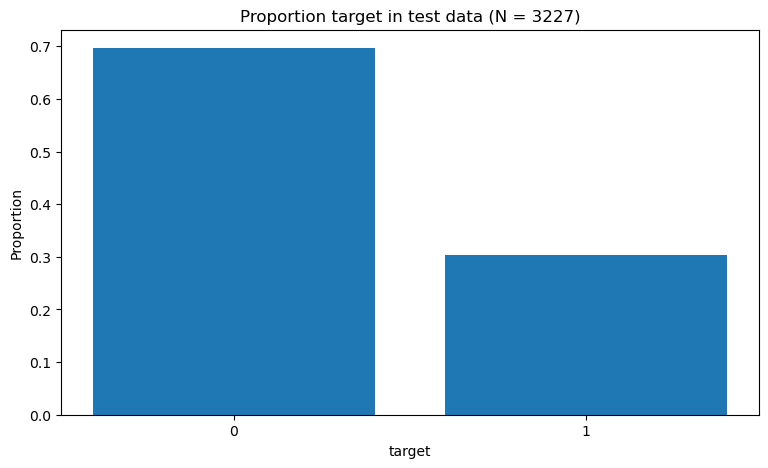

In [10]:
df_tmp = df[df['data_set'] == 'test'].copy()
int_n_rows = df_tmp.shape[0]
ser_freq = df_tmp[str_target].value_counts(normalize=True)
df_freq = ser_freq.reset_index()
df_freq.columns = [str_target, 'proportion']
df_freq.sort_values(by=str_target, ascending=True, inplace=True)
# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(f'Proportion target in test data (N = {int_n_rows})')
ax.set_xlabel(str_target)
ax.set_ylabel('Proportion')
ax.bar(df_freq['target'].astype(str), df_freq['proportion'])
plt.show()

### Show target in test data by BK type

  0%|          | 0/3 [00:00<?, ?it/s]

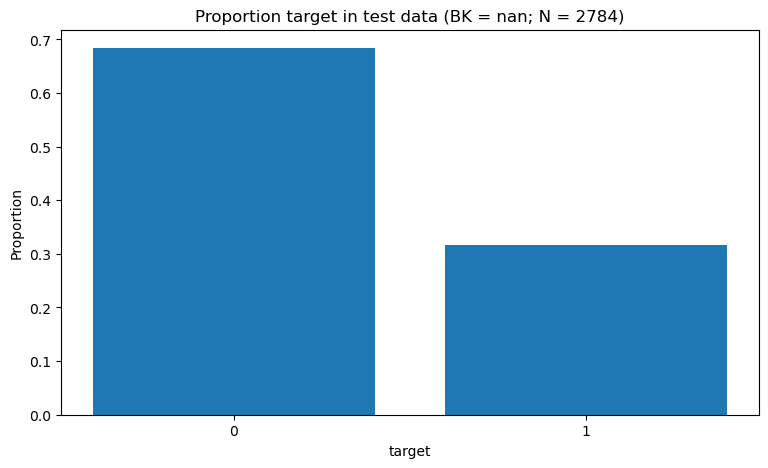

 33%|███▎      | 1/3 [00:00<00:00,  7.57it/s]

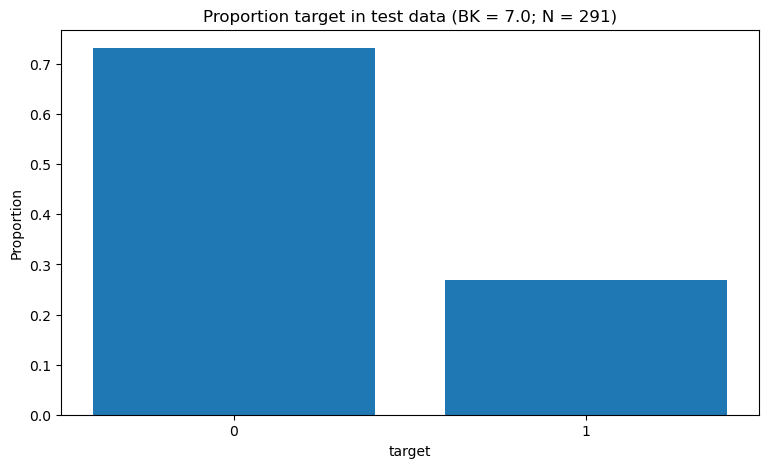

 67%|██████▋   | 2/3 [00:00<00:00,  8.22it/s]

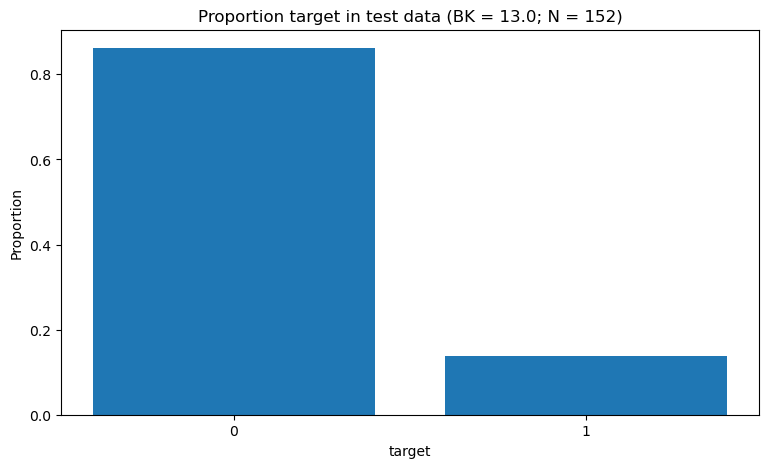

100%|██████████| 3/3 [00:00<00:00,  8.71it/s]


In [11]:
df_tmp = df[df['data_set'] == 'test'].copy()
list_str_bk = [
    'nan',
    '7.0',
    '13.0',
]
for str_bk in tqdm(list_str_bk):
    df_tmp_tmp = df_tmp[df_tmp['intopenbktype__app'] == str_bk].copy()
    int_n_rows = df_tmp_tmp.shape[0]
    ser_freq = df_tmp_tmp[str_target].value_counts(normalize=True)
    df_freq = ser_freq.reset_index()
    df_freq.columns = [str_target, 'proportion']
    df_freq.sort_values(by=str_target, ascending=True, inplace=True)
    # plot
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(f'Proportion target in test data (BK = {str_bk}; N = {int_n_rows})')
    ax.set_xlabel(str_target)
    ax.set_ylabel('Proportion')
    ax.bar(df_freq['target'].astype(str), df_freq['proportion'])
    plt.show()

### Get app month

In [12]:
# get app month
df['app_month'] = df[str_datecol].dt.to_period('M').dt.to_timestamp().astype(str)
df

,uniqueid__app_x,bigstatusid__app,strcity__app,strname__app,strzipcode__app,bitapproved__app,bitsystemdecline__app,approvaldate__app,bitfunded__app,fundeddate__app,...,data_set,year,factor,ENG-applicationdate__app_month,ENG-applicationdate__app_quarter,ENG-payment_to_income,ENG-loan_to_value,ENG-vehicle_age,ENG-dealership_age,app_month
12946,0__0__01/20/2022 18:06:14,0.0,glendale,arizona,85308,0.0,0.0,0.0,0.0,0.0,...,test,2022,1.0,1,1,0.12,1.485714,0.0,15.810959,2022-01-01
12590,5902037__7403866__20220120,0.0,ogden,utah,84401,1.0,nan,0.0,1.0,0.0,...,test,2022,1.0,1,1,0.09,1.615385,7.0,18.547945,2022-01-01
13218,0__0__20220120,0.0,mishawaka,indiana,46545,0.0,0.0,0.0,0.0,0.0,...,test,2022,1.0,1,1,0.12,1.441176,5.0,4.838356,2022-01-01
14629,0__0__20220120,0.0,columbus,ohio,43211,0.0,0.0,0.0,0.0,0.0,...,test,2022,1.0,1,1,0.15,1.241379,5.0,8.723288,2022-01-01
12750,0__0__01/20/2022 19:12:41,0.0,griffin,georgia,30224,0.0,0.0,0.0,0.0,0.0,...,test,2022,1.0,1,1,0.15,1.447368,1.0,11.928767,2022-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43795,0__0__20221228,11.0,mesa,arizona,85203,0.0,0.0,0.0,0.0,0.0,...,holdout,2022,1.0,12,4,0.12,1.242424,5.0,13.534247,2022-12-01
43720,0__0__20221228,11.0,tacoma,washington,98403,0.0,0.0,0.0,0.0,0.0,...,holdout,2022,1.0,12,4,0.09,1.444444,9.0,7.684932,2022-12-01
43819,0__0__20221229,11.0,union,missouri,63084,0.0,0.0,0.0,0.0,0.0,...,holdout,2022,1.0,12,4,0.15,1.365854,5.0,14.906849,2022-12-01
43820,0__0__20221229,11.0,union,missouri,63084,0.0,0.0,0.0,0.0,0.0,...,holdout,2022,1.0,12,4,0.12,1.365854,5.0,14.906849,2022-12-01


### Import model

In [13]:
str_filename = 'final_model.pkl'
str_bucket_path = f'{str_model}/02_model/{str_variant}/03_final_model/{str_filename}'
str_local_path = f'{str_dirname_output}/{str_filename}'
download_from_s3(
#     aws_access_key_id=AWS_ACCESS_KEY_ID, 
#     aws_secret_access_key=AWS_SECRET_ACCESS_KEY,
    str_local_path=str_local_path,
    str_bucket_path=str_bucket_path,
    str_project=str_project,
)
cls_model_inference = pickle.load(open(str_local_path, 'rb'))['model_inference']
os.remove(str_local_path)

### Get features in the model and corresponding catboost importance

In [14]:
list_cols_model = list(cls_model_inference.feature_names_)
list_flt_imp = cls_model_inference.feature_importances_
df_tmp = pd.DataFrame({
    'feature': list_cols_model,
    'importance': list_flt_imp,
})
df_tmp.sort_values(by='importance', ascending=False, inplace=True)

# get description
str_filename = 'data_dictionary.csv'
str_local_path = f'./input/{str_filename}'
df_desc = pd.read_csv(str_local_path)

# join
df_tmp = pd.merge(
    left=df_tmp,
    right=df_desc,
    on='feature',
    how='left',
)

# save
str_filename = 'df_imp.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
#df_tmp.to_csv(str_local_path, index=False)

# show
df_tmp

,feature,importance,Description
0,intopenbktype__app,4.408766,NaN
1,fltgrossmonthly__income_sum,3.135174,NaN
2,bankruptcystatus__ln,3.054178,Indicates status of most recent bankruptcy fil...
3,au21s__tu,2.953364,Months since most recent auto trade opened
4,g990s__tu,2.627512,Number of deduped inquiries in past 12 months
...,...,...,...
117,alertregulatorycondition__ln,0.056810,Indicates subject has an alert on their file t...
118,linka060__tu,0.038926,Total amount of open (unpaid) non-sufficient f...
119,linka015__tu,0.000000,Number of checking account closures for cause ...
120,ret225__tu,0.000000,Average total Payment Ratio for Retail account...


### SHAP values

In [15]:
# df_tmp = df[df['data_set'] == 'test'].copy()[list_cols_model]
# cls_explainer = shap.Explainer(cls_model_inference)
# df_shap = pd.DataFrame(cls_explainer.shap_values(df_tmp), columns=list_cols_model)
# # get means
# list_dict_row = []
# for col in tqdm(list_cols_model):
#     flt_mean = df_shap[col].mean()
#     dict_row = {
#         'feature': col,
#         'mean_shap': flt_mean,
#     }
#     list_dict_row.append(dict_row)
# df_tmp = pd.DataFrame(list_dict_row)
# df_tmp['mean_shap_abs'] = df_tmp['mean_shap'].apply(abs)
# df_tmp.sort_values(by='mean_shap_abs', ascending=False, inplace=True)

# # get description
# str_filename = 'data_dictionary.csv'
# str_local_path = f'./input/{str_filename}'
# df_desc = pd.read_csv(str_local_path)

# # join
# df_tmp = pd.merge(
#     left=df_tmp,
#     right=df_desc,
#     on='feature',
#     how='left',
# )

# # save
# str_filename = 'df_shap.csv'
# str_local_path = f'{str_dirname_output}/{str_filename}'
# df_tmp.to_csv(str_local_path, index=False)

# # show
# df_tmp

### Plot it

In [16]:
# flt_sum_shap = expit(df_tmp['mean_shap'].sum())
# df_tmp_pos = df_tmp[df_tmp['mean_shap'] >= 0].copy()
# df_tmp_pos.sort_values(by='mean_shap', ascending=True, inplace=True)
# df_tmp_neg = df_tmp[df_tmp['mean_shap'] < 0].copy()
# df_tmp_neg.sort_values(by='mean_shap', ascending=True, inplace=True)
# # plot
# fig, ax = plt.subplots(figsize=(5,20))
# ax.set_title(f'Mean SHAP by feature (Sum = {flt_sum_shap:0.4f})')
# # negative
# ax.barh(df_tmp_neg['feature'], df_tmp_neg['mean_shap'], color='red', label='Negative')
# # positive
# ax.barh(df_tmp_pos['feature'], df_tmp_pos['mean_shap'], color='blue', label='Positive')
# # legend
# plt.legend()
# # show
# plt.show()

### Generate predictions

In [17]:
# predict
df['yhat'] = cls_model_inference.predict_proba(df[list_cols_model])[:,1]
df

,uniqueid__app_x,bigstatusid__app,strcity__app,strname__app,strzipcode__app,bitapproved__app,bitsystemdecline__app,approvaldate__app,bitfunded__app,fundeddate__app,...,year,factor,ENG-applicationdate__app_month,ENG-applicationdate__app_quarter,ENG-payment_to_income,ENG-loan_to_value,ENG-vehicle_age,ENG-dealership_age,app_month,yhat
12946,0__0__01/20/2022 18:06:14,0.0,glendale,arizona,85308,0.0,0.0,0.0,0.0,0.0,...,2022,1.0,1,1,0.12,1.485714,0.0,15.810959,2022-01-01,0.239427
12590,5902037__7403866__20220120,0.0,ogden,utah,84401,1.0,nan,0.0,1.0,0.0,...,2022,1.0,1,1,0.09,1.615385,7.0,18.547945,2022-01-01,0.241901
13218,0__0__20220120,0.0,mishawaka,indiana,46545,0.0,0.0,0.0,0.0,0.0,...,2022,1.0,1,1,0.12,1.441176,5.0,4.838356,2022-01-01,0.333380
14629,0__0__20220120,0.0,columbus,ohio,43211,0.0,0.0,0.0,0.0,0.0,...,2022,1.0,1,1,0.15,1.241379,5.0,8.723288,2022-01-01,0.294446
12750,0__0__01/20/2022 19:12:41,0.0,griffin,georgia,30224,0.0,0.0,0.0,0.0,0.0,...,2022,1.0,1,1,0.15,1.447368,1.0,11.928767,2022-01-01,0.420149
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43795,0__0__20221228,11.0,mesa,arizona,85203,0.0,0.0,0.0,0.0,0.0,...,2022,1.0,12,4,0.12,1.242424,5.0,13.534247,2022-12-01,0.195951
43720,0__0__20221228,11.0,tacoma,washington,98403,0.0,0.0,0.0,0.0,0.0,...,2022,1.0,12,4,0.09,1.444444,9.0,7.684932,2022-12-01,0.301258
43819,0__0__20221229,11.0,union,missouri,63084,0.0,0.0,0.0,0.0,0.0,...,2022,1.0,12,4,0.15,1.365854,5.0,14.906849,2022-12-01,0.367784
43820,0__0__20221229,11.0,union,missouri,63084,0.0,0.0,0.0,0.0,0.0,...,2022,1.0,12,4,0.12,1.365854,5.0,14.906849,2022-12-01,0.348762


### Calculate residuals (predicted - actual)

In [18]:
df['residual'] = df['yhat'] - df[str_target]
df

,uniqueid__app_x,bigstatusid__app,strcity__app,strname__app,strzipcode__app,bitapproved__app,bitsystemdecline__app,approvaldate__app,bitfunded__app,fundeddate__app,...,factor,ENG-applicationdate__app_month,ENG-applicationdate__app_quarter,ENG-payment_to_income,ENG-loan_to_value,ENG-vehicle_age,ENG-dealership_age,app_month,yhat,residual
12946,0__0__01/20/2022 18:06:14,0.0,glendale,arizona,85308,0.0,0.0,0.0,0.0,0.0,...,1.0,1,1,0.12,1.485714,0.0,15.810959,2022-01-01,0.239427,0.239427
12590,5902037__7403866__20220120,0.0,ogden,utah,84401,1.0,nan,0.0,1.0,0.0,...,1.0,1,1,0.09,1.615385,7.0,18.547945,2022-01-01,0.241901,-0.758099
13218,0__0__20220120,0.0,mishawaka,indiana,46545,0.0,0.0,0.0,0.0,0.0,...,1.0,1,1,0.12,1.441176,5.0,4.838356,2022-01-01,0.333380,0.333380
14629,0__0__20220120,0.0,columbus,ohio,43211,0.0,0.0,0.0,0.0,0.0,...,1.0,1,1,0.15,1.241379,5.0,8.723288,2022-01-01,0.294446,-0.705554
12750,0__0__01/20/2022 19:12:41,0.0,griffin,georgia,30224,0.0,0.0,0.0,0.0,0.0,...,1.0,1,1,0.15,1.447368,1.0,11.928767,2022-01-01,0.420149,-0.579851
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43795,0__0__20221228,11.0,mesa,arizona,85203,0.0,0.0,0.0,0.0,0.0,...,1.0,12,4,0.12,1.242424,5.0,13.534247,2022-12-01,0.195951,0.195951
43720,0__0__20221228,11.0,tacoma,washington,98403,0.0,0.0,0.0,0.0,0.0,...,1.0,12,4,0.09,1.444444,9.0,7.684932,2022-12-01,0.301258,0.301258
43819,0__0__20221229,11.0,union,missouri,63084,0.0,0.0,0.0,0.0,0.0,...,1.0,12,4,0.15,1.365854,5.0,14.906849,2022-12-01,0.367784,-0.632216
43820,0__0__20221229,11.0,union,missouri,63084,0.0,0.0,0.0,0.0,0.0,...,1.0,12,4,0.12,1.365854,5.0,14.906849,2022-12-01,0.348762,-0.651238


### Split residuals into 3 groups

In [19]:
df['quantile'] = pd.qcut(df['residual'], q=3, labels=list(range(1, 3+1)))
df

,uniqueid__app_x,bigstatusid__app,strcity__app,strname__app,strzipcode__app,bitapproved__app,bitsystemdecline__app,approvaldate__app,bitfunded__app,fundeddate__app,...,ENG-applicationdate__app_month,ENG-applicationdate__app_quarter,ENG-payment_to_income,ENG-loan_to_value,ENG-vehicle_age,ENG-dealership_age,app_month,yhat,residual,quantile
12946,0__0__01/20/2022 18:06:14,0.0,glendale,arizona,85308,0.0,0.0,0.0,0.0,0.0,...,1,1,0.12,1.485714,0.0,15.810959,2022-01-01,0.239427,0.239427,2
12590,5902037__7403866__20220120,0.0,ogden,utah,84401,1.0,nan,0.0,1.0,0.0,...,1,1,0.09,1.615385,7.0,18.547945,2022-01-01,0.241901,-0.758099,1
13218,0__0__20220120,0.0,mishawaka,indiana,46545,0.0,0.0,0.0,0.0,0.0,...,1,1,0.12,1.441176,5.0,4.838356,2022-01-01,0.333380,0.333380,3
14629,0__0__20220120,0.0,columbus,ohio,43211,0.0,0.0,0.0,0.0,0.0,...,1,1,0.15,1.241379,5.0,8.723288,2022-01-01,0.294446,-0.705554,1
12750,0__0__01/20/2022 19:12:41,0.0,griffin,georgia,30224,0.0,0.0,0.0,0.0,0.0,...,1,1,0.15,1.447368,1.0,11.928767,2022-01-01,0.420149,-0.579851,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43795,0__0__20221228,11.0,mesa,arizona,85203,0.0,0.0,0.0,0.0,0.0,...,12,4,0.12,1.242424,5.0,13.534247,2022-12-01,0.195951,0.195951,2
43720,0__0__20221228,11.0,tacoma,washington,98403,0.0,0.0,0.0,0.0,0.0,...,12,4,0.09,1.444444,9.0,7.684932,2022-12-01,0.301258,0.301258,3
43819,0__0__20221229,11.0,union,missouri,63084,0.0,0.0,0.0,0.0,0.0,...,12,4,0.15,1.365854,5.0,14.906849,2022-12-01,0.367784,-0.632216,1
43820,0__0__20221229,11.0,union,missouri,63084,0.0,0.0,0.0,0.0,0.0,...,12,4,0.12,1.365854,5.0,14.906849,2022-12-01,0.348762,-0.651238,1


### Look at the SHAP values of those that were overpredicted 

In [20]:
# df_tmp = df[df['data_set'] == 'test'].copy()
# df_tmp_tmp = df_tmp[df_tmp['quantile'] == 1].copy()[list_cols_model]
# cls_explainer = shap.Explainer(cls_model_inference)
# df_shap = pd.DataFrame(cls_explainer.shap_values(df_tmp_tmp), columns=list_cols_model)
# # get means
# list_dict_row = []
# for col in tqdm(list_cols_model):
#     flt_mean = df_shap[col].mean()
#     dict_row = {
#         'feature': col,
#         'mean_shap_1': flt_mean,
#     }
#     list_dict_row.append(dict_row)
# df_tmp_1 = pd.DataFrame(list_dict_row)
# df_tmp_1.sort_values(by='mean_shap_1', ascending=False, inplace=True)
# # show
# df_tmp_1

### Look at the SHAP values that were predicted well

In [21]:
# df_tmp = df[df['data_set'] == 'test'].copy()
# df_tmp_tmp = df_tmp[df_tmp['quantile'] == 2].copy()[list_cols_model]
# cls_explainer = shap.Explainer(cls_model_inference)
# df_shap = pd.DataFrame(cls_explainer.shap_values(df_tmp_tmp), columns=list_cols_model)
# # get means
# list_dict_row = []
# for col in tqdm(list_cols_model):
#     flt_mean = df_shap[col].mean()
#     dict_row = {
#         'feature': col,
#         'mean_shap_2': flt_mean,
#     }
#     list_dict_row.append(dict_row)
# df_tmp_2 = pd.DataFrame(list_dict_row)
# df_tmp_2.sort_values(by='mean_shap_2', ascending=False, inplace=True)
# # show
# df_tmp_2

### Look at the SHAP values that were underpredicted

In [22]:
# df_tmp = df[df['data_set'] == 'test'].copy()
# df_tmp_tmp = df_tmp[df_tmp['quantile'] == 3].copy()[list_cols_model]
# cls_explainer = shap.Explainer(cls_model_inference)
# df_shap = pd.DataFrame(cls_explainer.shap_values(df_tmp_tmp), columns=list_cols_model)
# # get means
# list_dict_row = []
# for col in tqdm(list_cols_model):
#     flt_mean = df_shap[col].mean()
#     dict_row = {
#         'feature': col,
#         'mean_shap_3': flt_mean,
#     }
#     list_dict_row.append(dict_row)
# df_tmp_3 = pd.DataFrame(list_dict_row)
# df_tmp_3.sort_values(by='mean_shap_3', ascending=False, inplace=True)
# # show
# df_tmp_3

### Join so we can compare

In [23]:
# df_tmp = pd.merge(
#     left=df_tmp_1,
#     right=df_tmp_2,
#     on='feature',
#     how='inner',
# )
# df_tmp = pd.merge(
#     left=df_tmp,
#     right=df_tmp_3,
#     on='feature',
#     how='inner',
# )
# df_tmp['mean_shap_2_abs'] = df_tmp['mean_shap_2'].apply(abs)
# df_tmp.sort_values(by='mean_shap_2_abs', ascending=False, inplace=True)
# df_tmp.drop('mean_shap_2_abs', axis=1, inplace=True)

# # save
# str_filename = 'df_shap_comparison.csv'
# str_local_path = f'{str_dirname_output}/{str_filename}'
# df_tmp.to_csv(str_local_path, index=False)

# # show
# df_tmp

### Lift charts in test data

In [24]:
# list_cols_model_order = list(df_tmp['feature'])
# df_tmp = df[df['data_set'] == 'test'].copy()
# int_n_rows = df_tmp.shape[0]
# df_tmp['count'] = 1
# for col in tqdm(list_cols_model_order):
#     list_cols = [
#         col,
#         str_target,
#         'yhat',
#         'count',
#     ]
#     df_tmp_tmp = df_tmp[list_cols].copy()
#     # get number unique
#     int_n_unique = len(df_tmp_tmp[col].unique())
#     # logic
#     if int_n_unique >= 60:
#         # make quantiles
#         df_tmp_tmp[col] = pd.qcut(df_tmp['yhat'], q=20, labels=list(range(1, 20+1)))
#         # title
#         str_title = f'Mean predicted and actual by {col} quantile (N = {int_n_rows})'
#     else:
#         str_title = f'Mean predicted and actual by {col} (N = {int_n_rows})'

#     # group
#     df_grouped = df_tmp_tmp.groupby(by=col, as_index=False).agg({
#         str_target: 'mean',
#         'yhat': 'mean',
#         'count': 'sum',
#     })
#     # sort
#     df_grouped.sort_values(by=col, ascending=True, inplace=True)
#     # plot
#     fig, ax = plt.subplots(figsize=(6,3))
#     ax.set_title(str_title)
#     ax.set_xlabel(col)
#     ax.set_ylabel('Mean')
#     ax.plot(df_grouped[col], df_grouped['yhat'], label='Predicted')
#     ax.plot(df_grouped[col], df_grouped[str_target], label='Actual')
#     plt.legend(loc='upper left')
#     # count
#     ax2 = ax.twinx()
#     ax2.set_ylabel('Count')
#     ax2.plot(df_grouped[col], df_grouped['count'], linestyle='--', color='red', label='Count')
#     plt.legend(loc='lower right')
#     # show
#     plt.show()

### Distributions of predictions by data set

100%|██████████| 2/2 [00:01<00:00,  1.37it/s]


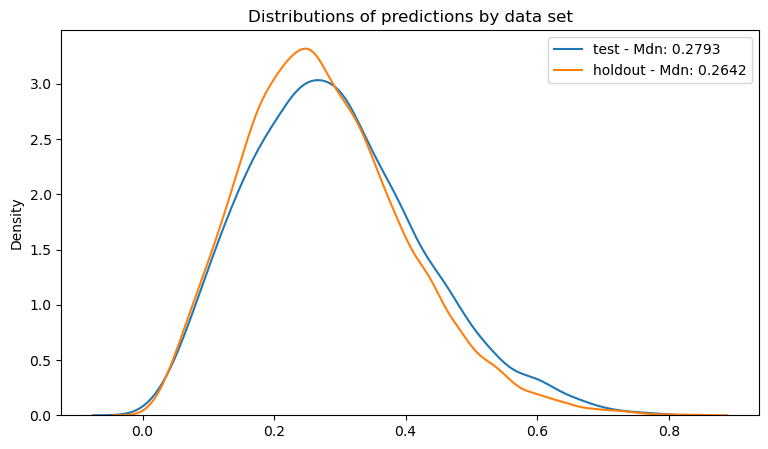

In [25]:
list_str_df = [
#     'train',
#     'valid',
    'test',
    'holdout',
]
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Distributions of predictions by data set')
for str_df in tqdm(list_str_df):
    df_tmp = df[df['data_set'] == str_df].copy()
    list_tmp = list(df_tmp['yhat'])
    flt_mdn = np.median(list_tmp)
    sns.kdeplot(list_tmp, ax=ax, label=f'{str_df} - Mdn: {flt_mdn:0.4f}')
plt.legend()
plt.show()

### Distributions of predictions in test by BK type

100%|██████████| 3/3 [00:00<00:00, 38.04it/s]


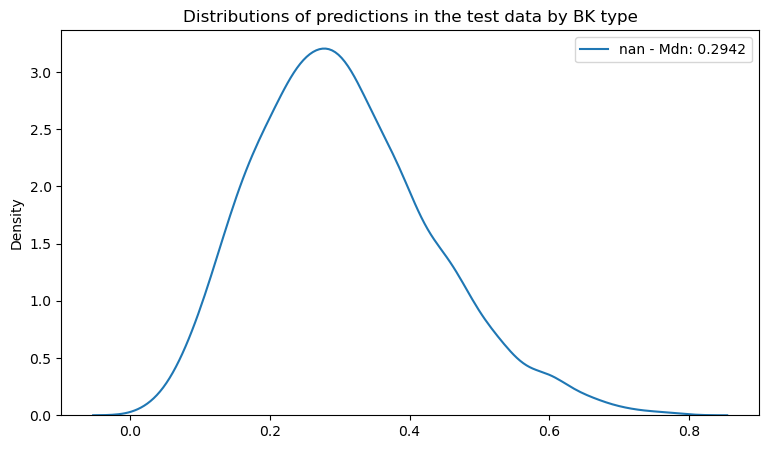

In [26]:
df_tmp = df[df['data_set'] == 'test'].copy()
df_tmp['intopenbktype__app'] = df_tmp['intopenbktype__app'].astype(str)
list_str_bk = [
    'nan',
    '7',
    '13',
]
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Distributions of predictions in the test data by BK type')
for str_bk in tqdm(list_str_bk):
    df_tmp_tmp = df_tmp[df_tmp['intopenbktype__app'] == str_bk].copy()
    list_tmp = list(df_tmp_tmp['yhat'])
    flt_mdn = np.median(list_tmp)
    sns.kdeplot(list_tmp, ax=ax, label=f'{str_bk} - Mdn: {flt_mdn:0.4f}')
plt.legend()
plt.show()

### Show mean predicted and actual over time

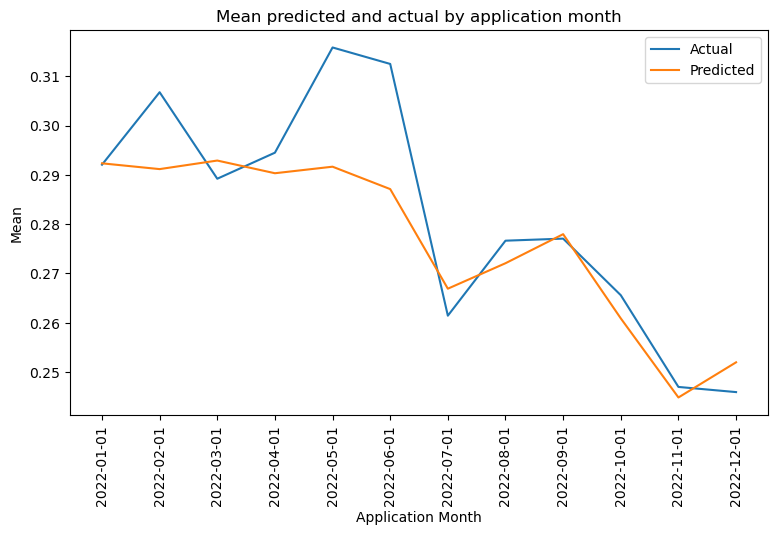

In [27]:
df_grouped = df.groupby('app_month', as_index=False).agg({
    str_target: 'mean',
    'yhat': 'mean',
})
# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Mean predicted and actual by application month')
ax.set_xlabel('Application Month')
ax.set_ylabel('Mean')
ax.plot(df_grouped['app_month'], df_grouped[str_target], label='Actual')
ax.plot(df_grouped['app_month'], df_grouped['yhat'], label='Predicted')
ax.set_xticklabels(df_grouped['app_month'], rotation=90)
plt.legend()
plt.show()

### Show mean predicted and actual over time by group

In [28]:
list_cols = [
    'app_month',
    'intopenbktype__app',
]
df_grouped = df.groupby(list_cols, as_index=False).agg({
    str_target: 'mean',
    'yhat': 'mean',
})
df_grouped

,app_month,intopenbktype__app,target,yhat
0,2022-01-01,13.0,0.121951,0.183267
1,2022-01-01,7.0,0.271429,0.217455
2,2022-01-01,nan,0.305380,0.307711
3,2022-02-01,13.0,0.144144,0.172380
4,2022-02-01,7.0,0.266968,0.213359
5,2022-02-01,nan,0.319238,0.305288
6,2022-03-01,13.0,0.097015,0.162321
7,2022-03-01,7.0,0.237931,0.216932
8,2022-03-01,nan,0.303954,0.307244
9,2022-04-01,13.0,0.149123,0.166935


### Actuals

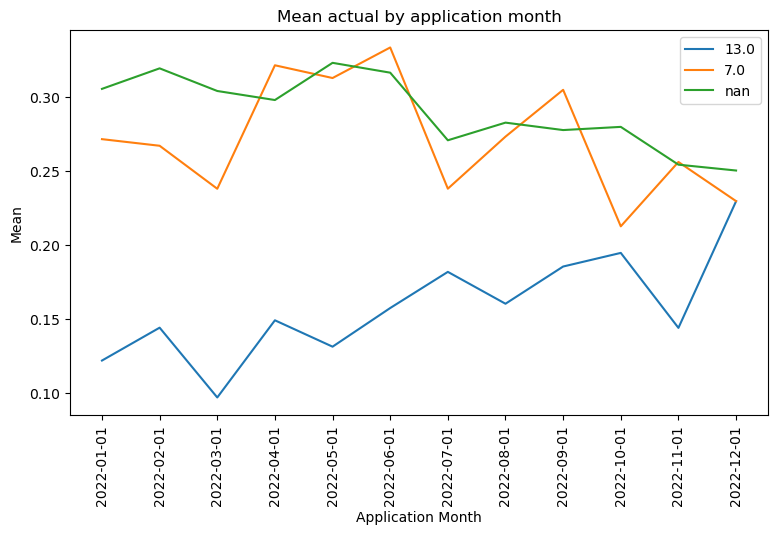

In [29]:
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Mean actual by application month')
ax.set_xlabel('Application Month')
ax.set_ylabel('Mean')
for str_bk in df_grouped['intopenbktype__app'].unique():
    df_tmp = df_grouped[df_grouped['intopenbktype__app'] == str_bk].copy()
    ax.plot(df_tmp['app_month'], df_tmp[str_target], label=str_bk)
ax.set_xticklabels(df_tmp['app_month'], rotation=90)
plt.legend()
plt.show()

### Predictions

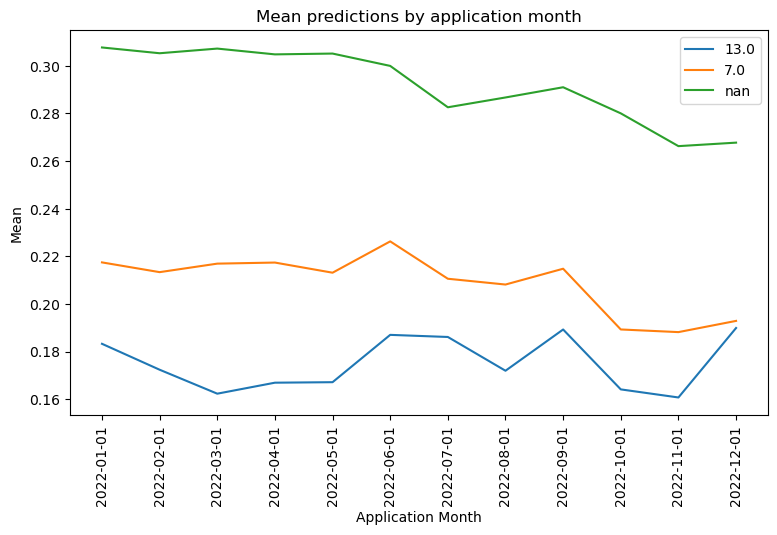

In [30]:
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Mean predictions by application month')
ax.set_xlabel('Application Month')
ax.set_ylabel('Mean')
for str_bk in df_grouped['intopenbktype__app'].unique():
    df_tmp = df_grouped[df_grouped['intopenbktype__app'] == str_bk].copy()
    ax.plot(df_tmp['app_month'], df_tmp['yhat'], label=str_bk)
ax.set_xticklabels(df_tmp['app_month'], rotation=90)
plt.legend()
plt.show()

### Non-BK

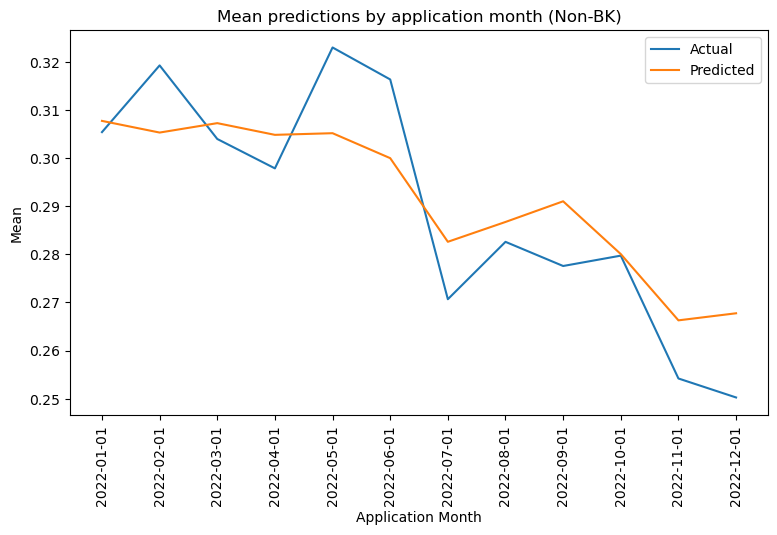

In [31]:
list_cols = [
    'app_month',
    'intopenbktype__app',
]
df_tmp = df[df['intopenbktype__app'] == 'nan'].copy()
df_grouped = df_tmp.groupby(list_cols, as_index=False).agg({
    str_target: 'mean',
    'yhat': 'mean',
})
# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(f'Mean predictions by application month (Non-BK)')
ax.set_xlabel('Application Month')
ax.set_ylabel('Mean')
ax.plot(df_grouped['app_month'], df_grouped[str_target], label='Actual')
ax.plot(df_grouped['app_month'], df_grouped['yhat'], label='Predicted')
ax.set_xticklabels(df_grouped['app_month'], rotation=90)
plt.legend()
plt.show()

### BK7

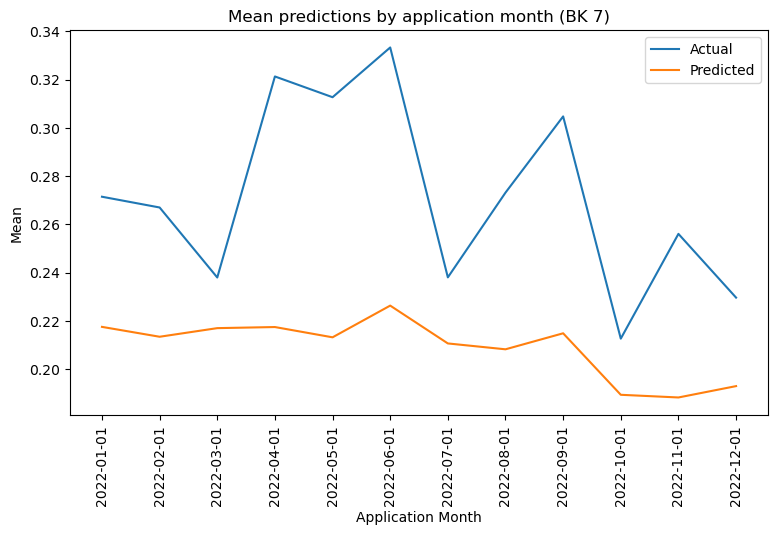

In [32]:
list_cols = [
    'app_month',
    'intopenbktype__app',
]
df_tmp = df[df['intopenbktype__app'] == '7.0'].copy()
df_grouped = df_tmp.groupby(list_cols, as_index=False).agg({
    str_target: 'mean',
    'yhat': 'mean',
})
# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(f'Mean predictions by application month (BK 7)')
ax.set_xlabel('Application Month')
ax.set_ylabel('Mean')
ax.plot(df_grouped['app_month'], df_grouped[str_target], label='Actual')
ax.plot(df_grouped['app_month'], df_grouped['yhat'], label='Predicted')
ax.set_xticklabels(df_grouped['app_month'], rotation=90)
plt.legend()
plt.show()

### BK13

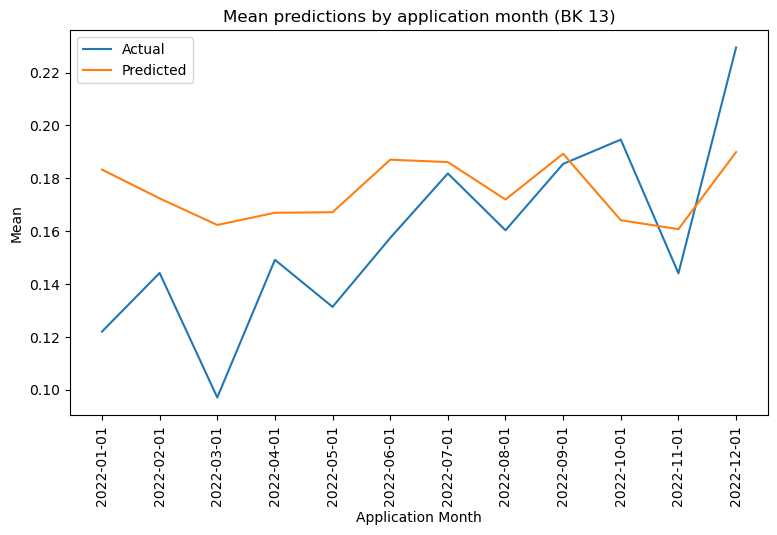

In [33]:
list_cols = [
    'app_month',
    'intopenbktype__app',
]
df_tmp = df[df['intopenbktype__app'] == '13.0'].copy()
df_grouped = df_tmp.groupby(list_cols, as_index=False).agg({
    str_target: 'mean',
    'yhat': 'mean',
})
# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(f'Mean predictions by application month (BK 13)')
ax.set_xlabel('Application Month')
ax.set_ylabel('Mean')
ax.plot(df_grouped['app_month'], df_grouped[str_target], label='Actual')
ax.plot(df_grouped['app_month'], df_grouped['yhat'], label='Predicted')
ax.set_xticklabels(df_grouped['app_month'], rotation=90)
plt.legend()
plt.show()

### Sorted predictions and actual (train)

In [34]:
# df_tmp = df[df['data_set'] == 'train'].copy()
# df_tmp['quantile'] = pd.qcut(df_tmp['yhat'], q=int_n_quantiles, labels=list(range(1, int_n_quantiles+1)))
# df_grouped = df_tmp.groupby('quantile', as_index=False).agg({
#     str_target: 'mean',
#     'yhat': 'mean',
# })
# # plot
# fig, ax = plt.subplots(figsize=(9,5))
# ax.set_title('Actual mean by prediction quantile (train)')
# ax.set_xlabel('Prediction Quantile')
# ax.set_ylabel('Mean')
# ax.plot(df_grouped['quantile'], df_grouped['yhat'], label='Predicted')
# ax.plot(df_grouped['quantile'], df_grouped[str_target], label='Actual')
# plt.legend()
# plt.show()

### Sorted predictions and actual (valid)

In [35]:
# df_tmp = df[df['data_set'] == 'valid'].copy()
# df_tmp['quantile'] = pd.qcut(df_tmp['yhat'], q=int_n_quantiles, labels=list(range(1, int_n_quantiles+1)))
# df_grouped = df_tmp.groupby('quantile', as_index=False).agg({
#     str_target: 'mean',
#     'yhat': 'mean',
# })
# # plot
# fig, ax = plt.subplots(figsize=(9,5))
# ax.set_title('Actual mean by prediction quantile (valid)')
# ax.set_xlabel('Prediction Quantile')
# ax.set_ylabel('Mean')
# ax.plot(df_grouped['quantile'], df_grouped['yhat'], label='Predicted')
# ax.plot(df_grouped['quantile'], df_grouped[str_target], label='Actual')
# plt.legend()
# plt.show()

### Sorted predictions and actual (test)

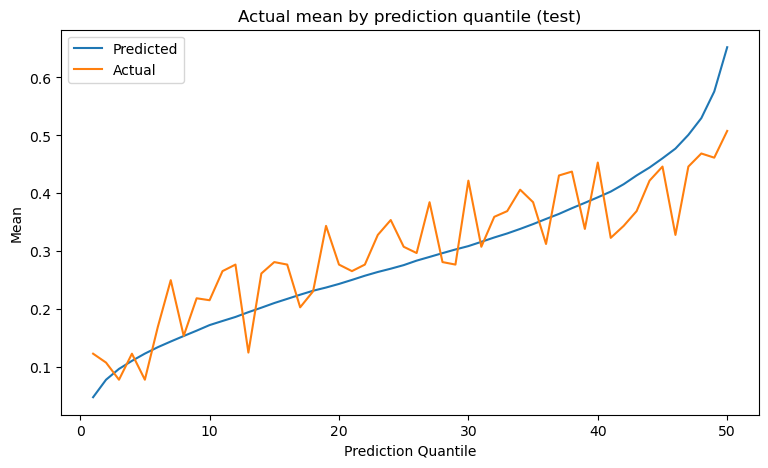

In [36]:
df_tmp = df[df['data_set'] == 'test'].copy()
df_tmp['quantile'] = pd.qcut(df_tmp['yhat'], q=int_n_quantiles, labels=list(range(1, int_n_quantiles+1)))
df_grouped = df_tmp.groupby('quantile', as_index=False).agg({
    str_target: 'mean',
    'yhat': 'mean',
})
# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Actual mean by prediction quantile (test)')
ax.set_xlabel('Prediction Quantile')
ax.set_ylabel('Mean')
ax.plot(df_grouped['quantile'], df_grouped['yhat'], label='Predicted')
ax.plot(df_grouped['quantile'], df_grouped[str_target], label='Actual')
plt.legend()
plt.show()

### Sorted predictions and actual (holdout)

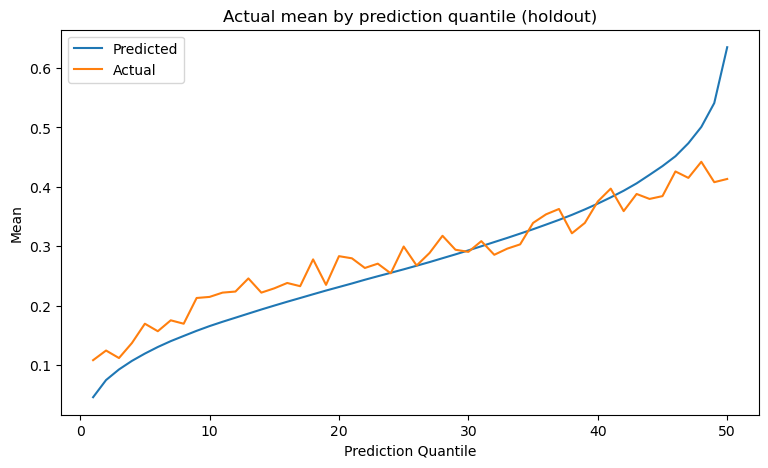

In [37]:
df_tmp = df[df['data_set'] == 'holdout'].copy()
df_tmp['quantile'] = pd.qcut(df_tmp['yhat'], q=int_n_quantiles, labels=list(range(1, int_n_quantiles+1)))
df_grouped = df_tmp.groupby('quantile', as_index=False).agg({
    str_target: 'mean',
    'yhat': 'mean',
})
# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Actual mean by prediction quantile (holdout)')
ax.set_xlabel('Prediction Quantile')
ax.set_ylabel('Mean')
ax.plot(df_grouped['quantile'], df_grouped['yhat'], label='Predicted')
ax.plot(df_grouped['quantile'], df_grouped[str_target], label='Actual')
plt.legend()
plt.show()

### Model evaluation metrics by data set

100%|██████████| 2/2 [00:01<00:00,  1.79it/s]


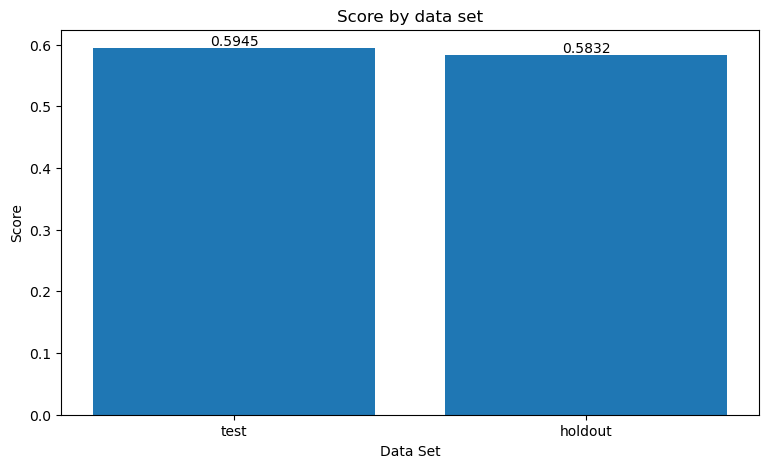

In [38]:
list_str_df = [
#     'train',
#     'valid',
    'test',
    'holdout',
]
list_dict_row = []
for str_df in tqdm(list_str_df):
    df_tmp = df[df['data_set'] == str_df].copy()
    # logic
    if str_eval_metric == 'AUC':
        flt_score = skm.roc_auc_score(y_true=df_tmp[str_target], y_score=df_tmp['yhat'])
    elif str_eval_metric == 'Logloss':
        flt_score = skm.log_loss(y_true=df_tmp[str_target], y_pred=df_tmp['yhat'])
    else:
        pass
    dict_row = {
        'data_set': str_df,
        'score': flt_score,
    }
    list_dict_row.append(dict_row)
df_tmp = pd.DataFrame(list_dict_row)

# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Score by data set')
ax.set_ylabel('Score')
ax.set_xlabel('Data Set')
bars = ax.bar(df_tmp['data_set'], df_tmp['score'])
# add labels to each bar
for bar in bars:
    # het height
    flt_height = bar.get_height()
    # add a label on top of the bar
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # x-coordinate of the label (centered on the bar)
        flt_height,                         # y-coordinate of the label (on top of the bar)
        f'{flt_height:0.4f}',               # Label text (the height of the bar)
        ha='center',                        # Horizontal alignment of the text
        va='bottom'                         # Vertical alignment of the text
    )
# show
plt.show()

### Model evaluation metrics in test by BK type

100%|██████████| 3/3 [00:00<00:00, 58.40it/s]


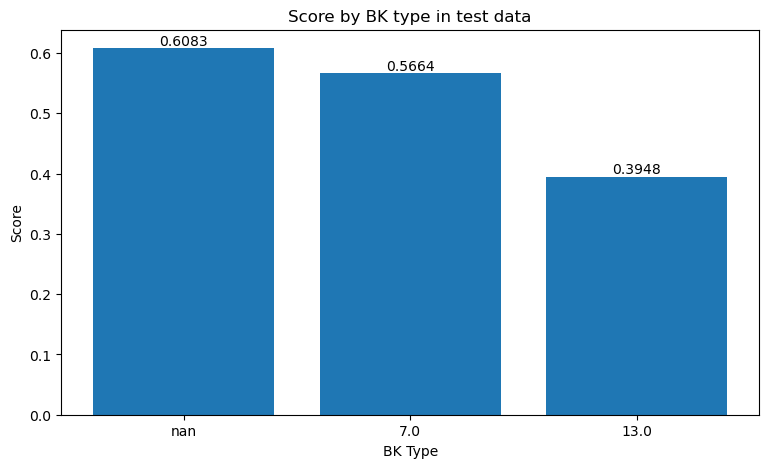

In [39]:
df_tmp = df[df['data_set'] == 'test'].copy()
list_str_bk = [
    'nan',
    '7.0',
    '13.0',
]
list_dict_row = []
for str_bk in tqdm(list_str_bk):
    df_tmp_tmp = df_tmp[df_tmp['intopenbktype__app'] == str_bk].copy()
    # logic
    if str_eval_metric == 'AUC':
        flt_score = skm.roc_auc_score(y_true=df_tmp_tmp[str_target], y_score=df_tmp_tmp['yhat'])
    elif str_eval_metric == 'Logloss':
        flt_score = skm.log_loss(y_true=df_tmp_tmp[str_target], y_pred=df_tmp_tmp['yhat'])
    else:
        pass
    dict_row = {
        'bk_type': str_bk,
        'score': flt_score,
    }
    list_dict_row.append(dict_row)
df_tmp = pd.DataFrame(list_dict_row)

# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Score by BK type in test data')
ax.set_ylabel('Score')
ax.set_xlabel('BK Type')
bars = ax.bar(df_tmp['bk_type'], df_tmp['score'])
# add labels to each bar
for bar in bars:
    # het height
    flt_height = bar.get_height()
    # add a label on top of the bar
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # x-coordinate of the label (centered on the bar)
        flt_height,                         # y-coordinate of the label (on top of the bar)
        f'{flt_height:0.4f}',               # Label text (the height of the bar)
        ha='center',                        # Horizontal alignment of the text
        va='bottom'                         # Vertical alignment of the text
    )
plt.show()